In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statistics as sts
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [27]:
df = pd.read_csv('./Amazon_bestsellers_items_2025.csv')
df

,Unnamed: 0,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,rank_change_label,country,page
0,0,1,B073VKKNN9,Kaspersky | Premium - Total Security (Ultimate...,₹469.00,4.3,13324.0,https://www.amazon.in/dp/B073VKKNN9,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
1,1,2,B07PQZJ6Y8,"K7 Security K7, Total Security, 1 User, 1 Year...",₹370.00,4.4,2291.0,https://www.amazon.in/dp/B07PQZJ6Y8,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
2,2,3,B0D1KL34JM,Microsoft Office 2021 Professional - Lifetime ...,"₹1,799.00",4.5,388.0,https://www.amazon.in/dp/B0D1KL34JM,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
3,3,4,B07B9YYLGG,"Bitdefender - 1 Device,1 Year - Mobile Securit...",₹94.00,4.1,9630.0,https://www.amazon.in/dp/B07B9YYLGG,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
4,4,5,B073VLGMZ4,"McAfee Total Protection 2025 | 1 Device, 3 Yea...","₹1,699.00",4.4,5783.0,https://www.amazon.in/dp/B073VLGMZ4,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
994,994,96,B0DP7LBGM1,Microsoft Windows Server 2025 Standard Edition...,"$1,561.01",NaN,NaN,https://www.amazon.com.mx/dp/B0DP7LBGM1,https://images-na.ssl-images-amazon.com/images...,NaN,MX,2
995,995,97,B0CFZNMZW6,Photoshop Elements 2024 and Premiere Elements ...,"$3,067.45",4.0,82.0,https://www.amazon.com.mx/dp/B0CFZNMZW6,https://images-na.ssl-images-amazon.com/images...,NaN,MX,2
996,996,98,B09H2BRVWZ,Microsoft Office Hogar y Empresa 2021,"$5,999.00",4.9,12.0,https://www.amazon.com.mx/dp/B09H2BRVWZ,https://images-na.ssl-images-amazon.com/images...,NaN,MX,2
997,997,99,B0C55NKHKL,"Virtual DJ and Karaoke Studio 8, Lifetime, 1 D...",NaN,3.7,3.0,https://www.amazon.com.mx/dp/B0C55NKHKL,https://images-na.ssl-images-amazon.com/images...,NaN,MX,2


## Limpieza de datos

In [7]:
print(df.shape)
df.head()

(999, 12)


,Unnamed: 0,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,rank_change_label,country,page
0,0,1,B073VKKNN9,Kaspersky | Premium - Total Security (Ultimate...,₹469.00,4.3,13324.0,https://www.amazon.in/dp/B073VKKNN9,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
1,1,2,B07PQZJ6Y8,"K7 Security K7, Total Security, 1 User, 1 Year...",₹370.00,4.4,2291.0,https://www.amazon.in/dp/B07PQZJ6Y8,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
2,2,3,B0D1KL34JM,Microsoft Office 2021 Professional - Lifetime ...,"₹1,799.00",4.5,388.0,https://www.amazon.in/dp/B0D1KL34JM,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
3,3,4,B07B9YYLGG,"Bitdefender - 1 Device,1 Year - Mobile Securit...",₹94.00,4.1,9630.0,https://www.amazon.in/dp/B07B9YYLGG,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1
4,4,5,B073VLGMZ4,"McAfee Total Protection 2025 | 1 Device, 3 Yea...","₹1,699.00",4.4,5783.0,https://www.amazon.in/dp/B073VLGMZ4,https://images-eu.ssl-images-amazon.com/images...,NaN,IN,1


In [8]:
df.info()
print('------')
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           999 non-null    int64  
 1   rank                 999 non-null    int64  
 2   asin                 999 non-null    object 
 3   product_title        999 non-null    object 
 4   product_price        945 non-null    object 
 5   product_star_rating  969 non-null    float64
 6   product_num_ratings  969 non-null    float64
 7   product_url          999 non-null    object 
 8   product_photo        999 non-null    object 
 9   rank_change_label    0 non-null      float64
 10  country              999 non-null    object 
 11  page                 999 non-null    int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.8+ KB
------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 12 columns):
 #   Column         

### Datos faltantes

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           999 non-null    int64  
 1   rank                 999 non-null    int64  
 2   asin                 999 non-null    object 
 3   product_title        999 non-null    object 
 4   product_price        945 non-null    object 
 5   product_star_rating  969 non-null    float64
 6   product_num_ratings  969 non-null    float64
 7   product_url          999 non-null    object 
 8   product_photo        999 non-null    object 
 9   rank_change_label    0 non-null      float64
 10  country              999 non-null    object 
 11  page                 999 non-null    int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.8+ KB


In [29]:
df.drop(columns=['rank_change_label', 'Unnamed: 0'], inplace = True)
df

,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,country,page
0,1,B073VKKNN9,Kaspersky | Premium - Total Security (Ultimate...,₹469.00,4.3,13324.0,https://www.amazon.in/dp/B073VKKNN9,https://images-eu.ssl-images-amazon.com/images...,IN,1
1,2,B07PQZJ6Y8,"K7 Security K7, Total Security, 1 User, 1 Year...",₹370.00,4.4,2291.0,https://www.amazon.in/dp/B07PQZJ6Y8,https://images-eu.ssl-images-amazon.com/images...,IN,1
2,3,B0D1KL34JM,Microsoft Office 2021 Professional - Lifetime ...,"₹1,799.00",4.5,388.0,https://www.amazon.in/dp/B0D1KL34JM,https://images-eu.ssl-images-amazon.com/images...,IN,1
3,4,B07B9YYLGG,"Bitdefender - 1 Device,1 Year - Mobile Securit...",₹94.00,4.1,9630.0,https://www.amazon.in/dp/B07B9YYLGG,https://images-eu.ssl-images-amazon.com/images...,IN,1
4,5,B073VLGMZ4,"McAfee Total Protection 2025 | 1 Device, 3 Yea...","₹1,699.00",4.4,5783.0,https://www.amazon.in/dp/B073VLGMZ4,https://images-eu.ssl-images-amazon.com/images...,IN,1
...,...,...,...,...,...,...,...,...,...,...
994,96,B0DP7LBGM1,Microsoft Windows Server 2025 Standard Edition...,"$1,561.01",NaN,NaN,https://www.amazon.com.mx/dp/B0DP7LBGM1,https://images-na.ssl-images-amazon.com/images...,MX,2
995,97,B0CFZNMZW6,Photoshop Elements 2024 and Premiere Elements ...,"$3,067.45",4.0,82.0,https://www.amazon.com.mx/dp/B0CFZNMZW6,https://images-na.ssl-images-amazon.com/images...,MX,2
996,98,B09H2BRVWZ,Microsoft Office Hogar y Empresa 2021,"$5,999.00",4.9,12.0,https://www.amazon.com.mx/dp/B09H2BRVWZ,https://images-na.ssl-images-amazon.com/images...,MX,2
997,99,B0C55NKHKL,"Virtual DJ and Karaoke Studio 8, Lifetime, 1 D...",NaN,3.7,3.0,https://www.amazon.com.mx/dp/B0C55NKHKL,https://images-na.ssl-images-amazon.com/images...,MX,2


In [30]:
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 915 entries, 0 to 998
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rank                 915 non-null    int64  
 1   asin                 915 non-null    object 
 2   product_title        915 non-null    object 
 3   product_price        915 non-null    object 
 4   product_star_rating  915 non-null    float64
 5   product_num_ratings  915 non-null    float64
 6   product_url          915 non-null    object 
 7   product_photo        915 non-null    object 
 8   country              915 non-null    object 
 9   page                 915 non-null    int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 78.6+ KB


In [31]:
cols_cat = ['asin','product_title','product_price', 'product_url', 'product_photo','country']

for col in cols_cat:
    print(f'Columna {col}: {df[col].nunique()} subniveles')

Columna asin: 879 subniveles
Columna product_title: 892 subniveles
Columna product_price: 579 subniveles
Columna product_url: 915 subniveles
Columna product_photo: 867 subniveles
Columna country: 10 subniveles


In [32]:
df.describe()

,rank,product_star_rating,product_num_ratings,page
count,915.000000,915.000000,915.000000,915.000000
mean,49.574863,4.138142,1285.884153,1.484153
std,28.774602,0.490075,2945.835654,0.500022
min,1.000000,1.000000,1.000000,1.000000
25%,25.000000,3.900000,58.000000,1.000000
50%,49.000000,4.200000,223.000000,1.000000
75%,75.000000,4.400000,1009.000000,2.000000
max,100.000000,5.000000,19189.000000,2.000000


In [33]:
df.describe(exclude=[np.number])

,asin,product_title,product_price,product_url,product_photo,country
count,915,915,915,915,915,915
unique,879,892,579,915,867,10
top,B09MYJ1R6L,Laplink PCmover Ultimate 11 - Migration of you...,"39,99 €",https://www.amazon.com.mx/dp/B091KJH72X,https://images-eu.ssl-images-amazon.com/images...,IN
freq,3,4,21,1,5,100


### Filas repetidas

In [34]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df.shape}')
df.drop_duplicates(inplace = True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df.shape}')

Tamaño del set antes de eliminar las filas repetidas: (915, 10)
Tamaño del set después de eliminar las filas repetidas: (915, 10)


In [35]:
def calcular_iqr(data):
    #Calcular cuartiles 1 y 3
    qs = data.quantile([0.25, 0.75])

    #Calcular IQR
    iqr = qs[0.75] - qs[0.25]
    return iqr, qs[0.25], qs[0.75]

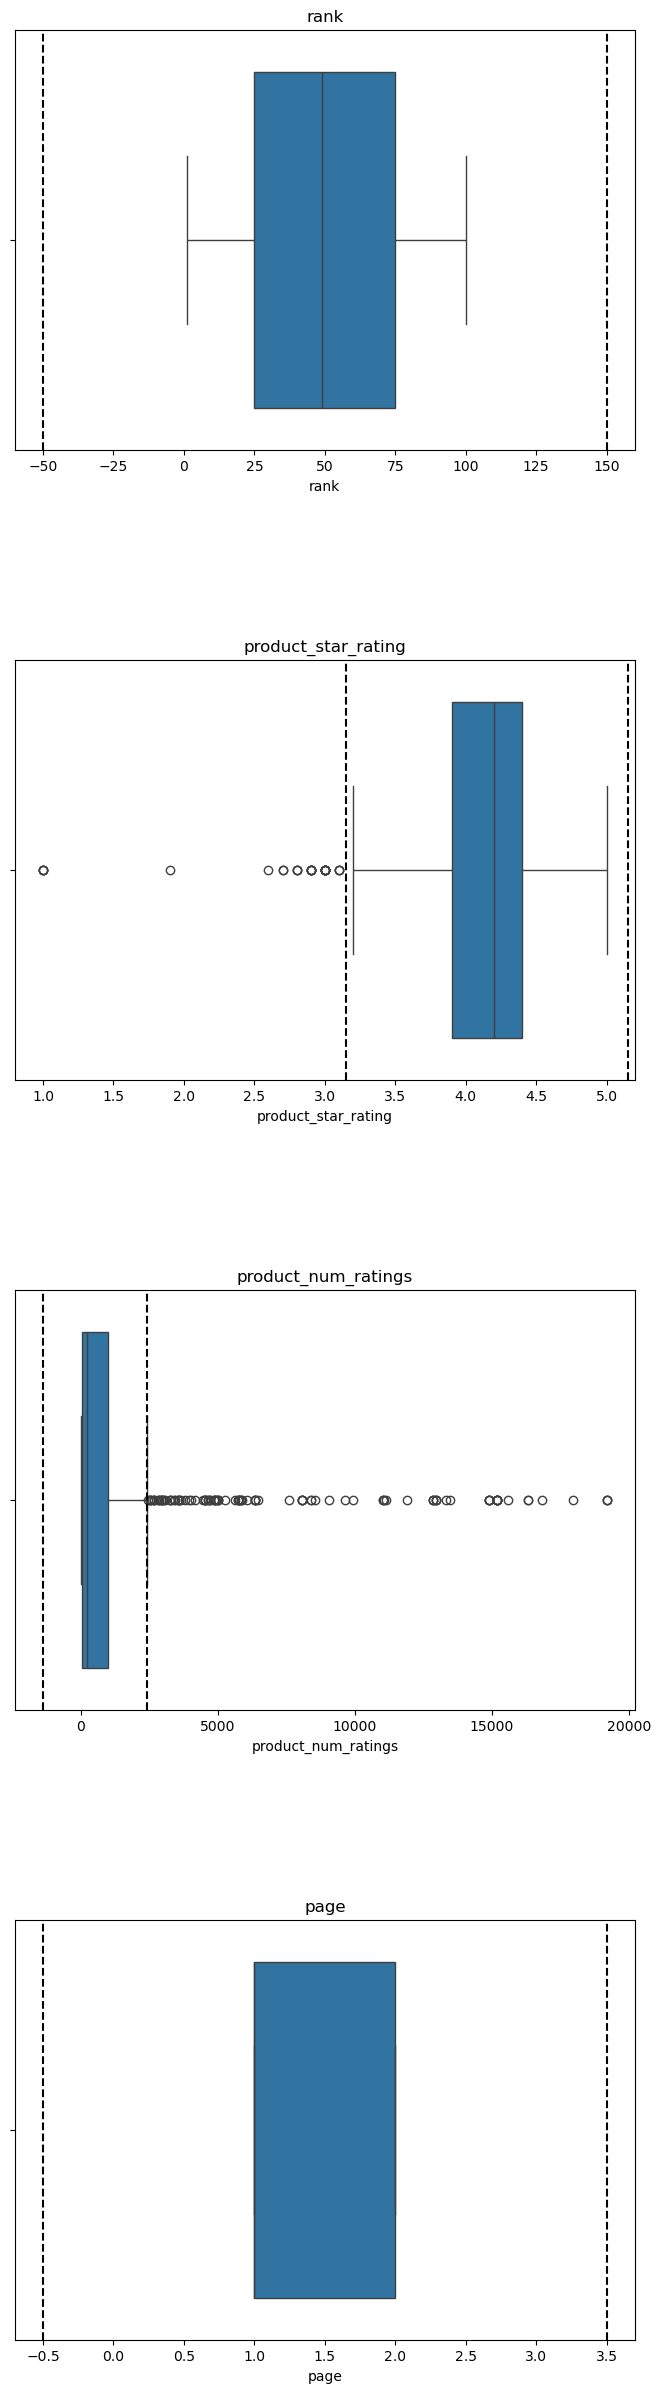

In [37]:
cols_num = ['rank','product_star_rating','product_num_ratings','page']

fig, ax = plt.subplots(nrows = 4, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace = 0.5)

for i, col in enumerate(cols_num):
    IQR, Q1, Q3 = calcular_iqr(df[col])
    sns.boxplot(x=col, data = df, ax = ax[i])
    ax[i].axvline((Q1-(1.5*IQR)), color = 'black', linestyle='--')
    ax[i].axvline((Q3+(1.5*IQR)), color = 'black', linestyle='--')
    ax[i].set_title(col)

## Analizamos los top sellers de México

In [45]:
df_Mexico = df[df['country'] == 'MX']
df_Mexico

,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,country,page
899,1,B09FR4MTK8,Microsoft 365 Familia (12 Meses) - Standard - ...,"$1,929.00",4.6,469.0,https://www.amazon.com.mx/dp/B09FR4MTK8,https://images-na.ssl-images-amazon.com/images...,MX,1
900,2,B09FRYNWPD,Microsoft 365 Personal (12 Meses) - Standard -...,"$1,569.00",4.6,471.0,https://www.amazon.com.mx/dp/B09FRYNWPD,https://images-na.ssl-images-amazon.com/images...,MX,1
901,3,B0DJPWBBJV,Microsoft Office Home 2024 | Apps clásicas: Wo...,"$2,649.00",4.4,22.0,https://www.amazon.com.mx/dp/B0DJPWBBJV,https://images-na.ssl-images-amazon.com/images...,MX,1
902,4,B086XTW6WF,Microsoft 365 Personal | Suscripción anual | P...,"$1,770.00",4.7,947.0,https://www.amazon.com.mx/dp/B086XTW6WF,https://images-na.ssl-images-amazon.com/images...,MX,1
904,6,B0B5T2J8TG,Corel PaintShop Pro 2023 Ultimate | Potente so...,"$2,221.85",4.0,157.0,https://www.amazon.com.mx/dp/B0B5T2J8TG,https://images-na.ssl-images-amazon.com/images...,MX,1
...,...,...,...,...,...,...,...,...,...,...
991,93,B0CM553HKF,Moho Debut 14 | Animation software for PC and ...,"$1,284.49",4.1,56.0,https://www.amazon.com.mx/dp/B0CM553HKF,https://images-na.ssl-images-amazon.com/images...,MX,2
993,95,B0D2CZPL7T,CLIP STUDIO PAINT PRO - Version 3 | Perpetual ...,"$1,429.03",4.9,15.0,https://www.amazon.com.mx/dp/B0D2CZPL7T,https://images-na.ssl-images-amazon.com/images...,MX,2
995,97,B0CFZNMZW6,Photoshop Elements 2024 and Premiere Elements ...,"$3,067.45",4.0,82.0,https://www.amazon.com.mx/dp/B0CFZNMZW6,https://images-na.ssl-images-amazon.com/images...,MX,2
996,98,B09H2BRVWZ,Microsoft Office Hogar y Empresa 2021,"$5,999.00",4.9,12.0,https://www.amazon.com.mx/dp/B09H2BRVWZ,https://images-na.ssl-images-amazon.com/images...,MX,2


In [41]:
cols_cat = ['asin','product_title','product_price', 'product_url', 'product_photo','country']

for col in cols_cat:
    print(f'Columna {col}: {df_Mexico[col].nunique()} subniveles')

Columna asin: 78 subniveles
Columna product_title: 77 subniveles
Columna product_price: 72 subniveles
Columna product_url: 78 subniveles
Columna product_photo: 77 subniveles
Columna country: 1 subniveles


Como podemos observar, en la columna 'country' solo hay un subnivel, esto es debido a que el dataframe esta filtrado y solo estamos utilizando MX, por lo tanto vamos a eliminar esta columna

In [46]:
df_Mexico.drop(columns = 'country', inplace = True)
df_Mexico

,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,page
899,1,B09FR4MTK8,Microsoft 365 Familia (12 Meses) - Standard - ...,"$1,929.00",4.6,469.0,https://www.amazon.com.mx/dp/B09FR4MTK8,https://images-na.ssl-images-amazon.com/images...,1
900,2,B09FRYNWPD,Microsoft 365 Personal (12 Meses) - Standard -...,"$1,569.00",4.6,471.0,https://www.amazon.com.mx/dp/B09FRYNWPD,https://images-na.ssl-images-amazon.com/images...,1
901,3,B0DJPWBBJV,Microsoft Office Home 2024 | Apps clásicas: Wo...,"$2,649.00",4.4,22.0,https://www.amazon.com.mx/dp/B0DJPWBBJV,https://images-na.ssl-images-amazon.com/images...,1
902,4,B086XTW6WF,Microsoft 365 Personal | Suscripción anual | P...,"$1,770.00",4.7,947.0,https://www.amazon.com.mx/dp/B086XTW6WF,https://images-na.ssl-images-amazon.com/images...,1
904,6,B0B5T2J8TG,Corel PaintShop Pro 2023 Ultimate | Potente so...,"$2,221.85",4.0,157.0,https://www.amazon.com.mx/dp/B0B5T2J8TG,https://images-na.ssl-images-amazon.com/images...,1
...,...,...,...,...,...,...,...,...,...
991,93,B0CM553HKF,Moho Debut 14 | Animation software for PC and ...,"$1,284.49",4.1,56.0,https://www.amazon.com.mx/dp/B0CM553HKF,https://images-na.ssl-images-amazon.com/images...,2
993,95,B0D2CZPL7T,CLIP STUDIO PAINT PRO - Version 3 | Perpetual ...,"$1,429.03",4.9,15.0,https://www.amazon.com.mx/dp/B0D2CZPL7T,https://images-na.ssl-images-amazon.com/images...,2
995,97,B0CFZNMZW6,Photoshop Elements 2024 and Premiere Elements ...,"$3,067.45",4.0,82.0,https://www.amazon.com.mx/dp/B0CFZNMZW6,https://images-na.ssl-images-amazon.com/images...,2
996,98,B09H2BRVWZ,Microsoft Office Hogar y Empresa 2021,"$5,999.00",4.9,12.0,https://www.amazon.com.mx/dp/B09H2BRVWZ,https://images-na.ssl-images-amazon.com/images...,2


La columna 'product_price' esta definida con un tipo de dato objeto, lo cual no es correcto debido a que en esta columna se esta almacenando el precio del producto y esta columna debería de estar como un dato numérico, por lo tanto vamos a normalizar esto

In [47]:
df_Mexico['product_price'] = (df_Mexico['product_price'].str.replace(r"[^0-9.]", "", regex=True).astype(float))
df_Mexico

,rank,asin,product_title,product_price,product_star_rating,product_num_ratings,product_url,product_photo,page
899,1,B09FR4MTK8,Microsoft 365 Familia (12 Meses) - Standard - ...,1929.00,4.6,469.0,https://www.amazon.com.mx/dp/B09FR4MTK8,https://images-na.ssl-images-amazon.com/images...,1
900,2,B09FRYNWPD,Microsoft 365 Personal (12 Meses) - Standard -...,1569.00,4.6,471.0,https://www.amazon.com.mx/dp/B09FRYNWPD,https://images-na.ssl-images-amazon.com/images...,1
901,3,B0DJPWBBJV,Microsoft Office Home 2024 | Apps clásicas: Wo...,2649.00,4.4,22.0,https://www.amazon.com.mx/dp/B0DJPWBBJV,https://images-na.ssl-images-amazon.com/images...,1
902,4,B086XTW6WF,Microsoft 365 Personal | Suscripción anual | P...,1770.00,4.7,947.0,https://www.amazon.com.mx/dp/B086XTW6WF,https://images-na.ssl-images-amazon.com/images...,1
904,6,B0B5T2J8TG,Corel PaintShop Pro 2023 Ultimate | Potente so...,2221.85,4.0,157.0,https://www.amazon.com.mx/dp/B0B5T2J8TG,https://images-na.ssl-images-amazon.com/images...,1
...,...,...,...,...,...,...,...,...,...
991,93,B0CM553HKF,Moho Debut 14 | Animation software for PC and ...,1284.49,4.1,56.0,https://www.amazon.com.mx/dp/B0CM553HKF,https://images-na.ssl-images-amazon.com/images...,2
993,95,B0D2CZPL7T,CLIP STUDIO PAINT PRO - Version 3 | Perpetual ...,1429.03,4.9,15.0,https://www.amazon.com.mx/dp/B0D2CZPL7T,https://images-na.ssl-images-amazon.com/images...,2
995,97,B0CFZNMZW6,Photoshop Elements 2024 and Premiere Elements ...,3067.45,4.0,82.0,https://www.amazon.com.mx/dp/B0CFZNMZW6,https://images-na.ssl-images-amazon.com/images...,2
996,98,B09H2BRVWZ,Microsoft Office Hogar y Empresa 2021,5999.00,4.9,12.0,https://www.amazon.com.mx/dp/B09H2BRVWZ,https://images-na.ssl-images-amazon.com/images...,2


### Valores atipicos en las variables numericas

In [49]:
df_Mexico.describe()

,rank,product_price,product_star_rating,product_num_ratings,page
count,78.000000,78.000000,78.000000,78.000000,78.000000
mean,48.833333,2161.549103,4.151282,375.192308,1.461538
std,28.072456,2419.055156,0.724299,521.438023,0.501745
min,1.000000,345.000000,1.000000,1.000000,1.000000
25%,25.500000,745.250000,4.000000,13.000000,1.000000
50%,46.500000,1433.620000,4.300000,105.000000,1.000000
75%,72.500000,2434.100000,4.600000,664.250000,2.000000
max,100.000000,12739.000000,5.000000,2350.000000,2.000000


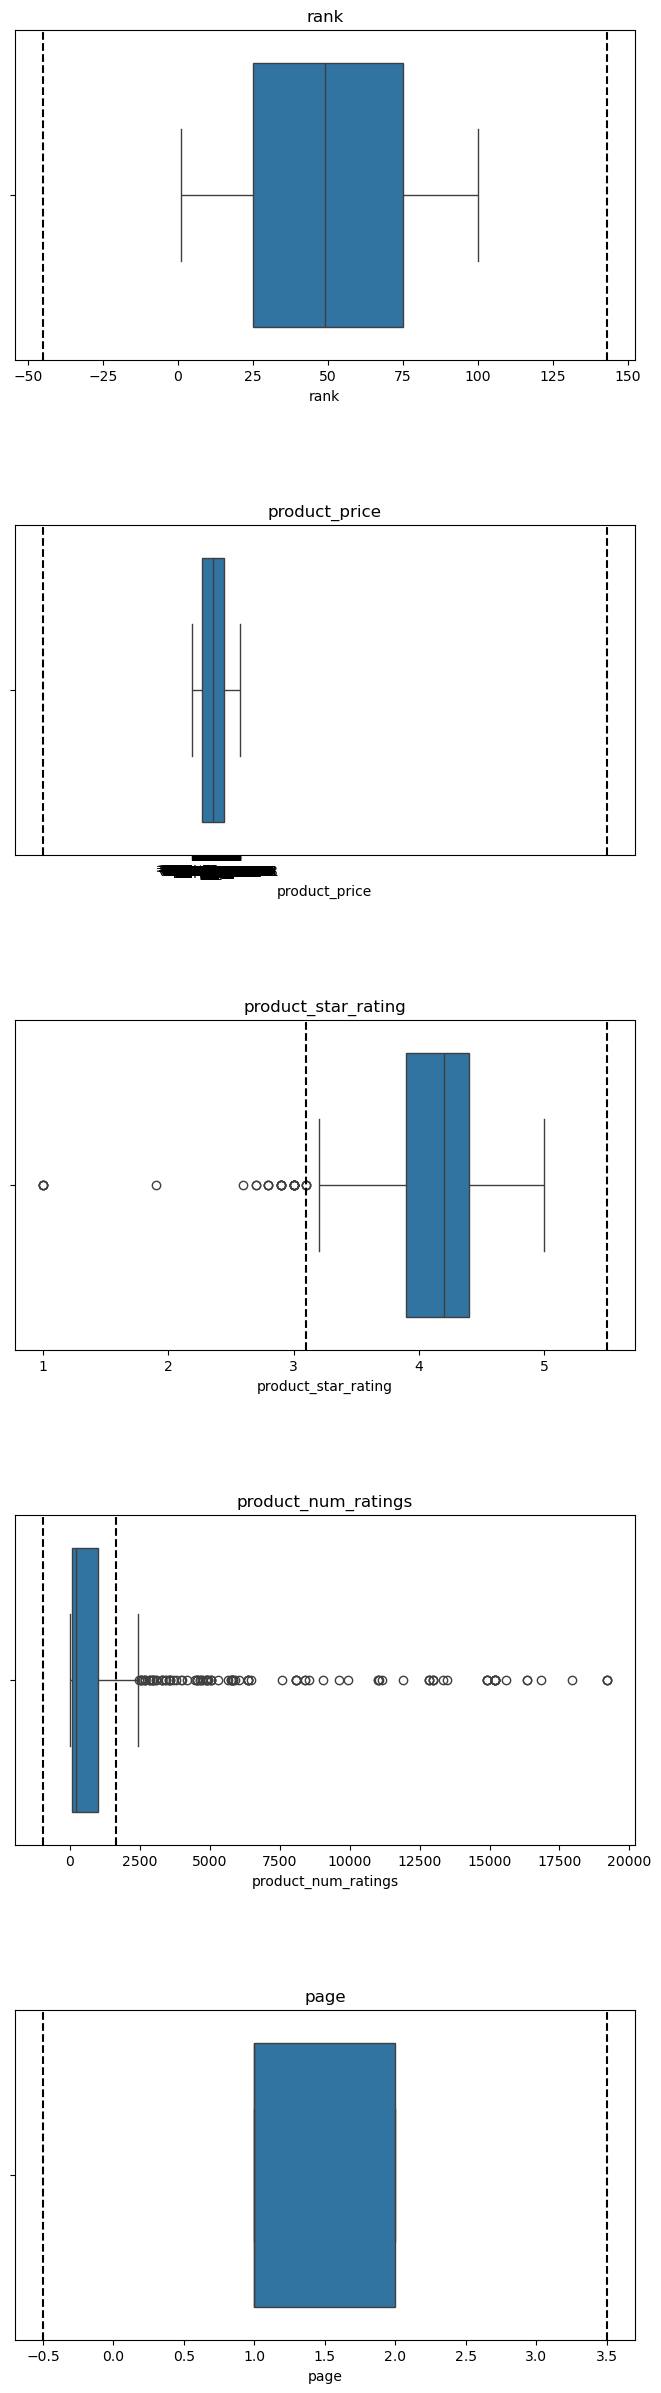

In [53]:
cols_num = ['rank','product_price','product_star_rating','product_num_ratings','page']

fig, ax = plt.subplots(nrows = 5, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace = 0.5)

for i, col in enumerate(cols_num):
    IQR, Q1, Q3 = calcular_iqr(df_Mexico[col])
    sns.boxplot(x=col, data = df, ax = ax[i])
    ax[i].axvline((Q1-(1.5*IQR)), color = 'black', linestyle='--')
    ax[i].axvline((Q3+(1.5*IQR)), color = 'black', linestyle='--')
    ax[i].set_title(col)

In [51]:
df_Mexico.describe(exclude=[np.number])

,asin,product_title,product_url,product_photo
count,78,78,78,78
unique,78,77,78,77
top,B09FR4MTK8,Yamaha AG 08 Mezclador de transmisión en vivo ...,https://www.amazon.com.mx/dp/B09FR4MTK8,https://images-na.ssl-images-amazon.com/images...
freq,1,2,1,2


Text(0, 0.5, 'Frecuencia')

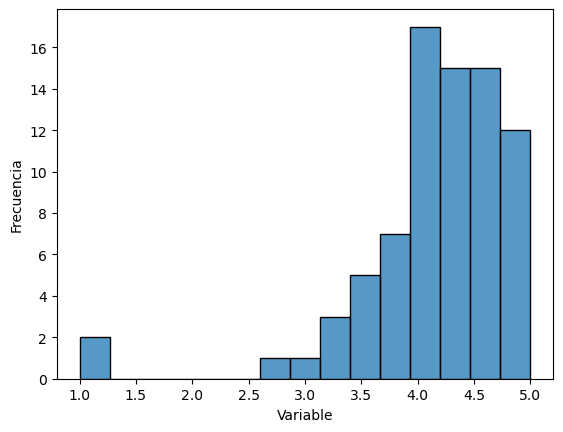

In [54]:
ax = sns.histplot(data=df_Mexico['product_star_rating'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia')

Text(0, 0.5, 'Densidades de probabilidad')

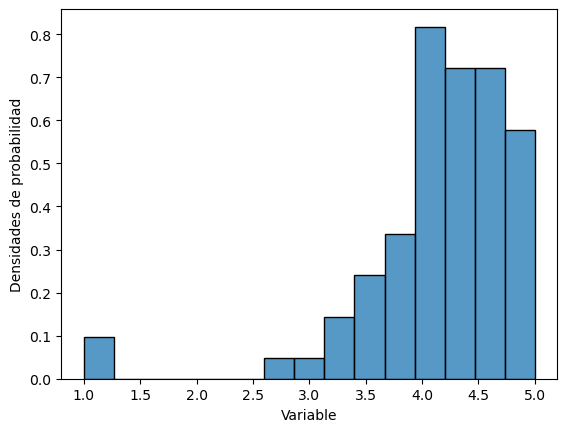

In [56]:
ax = sns.histplot(data=df_Mexico['product_star_rating'], stat='density')
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

Text(0, 0.5, 'Densidades de probabilidad')

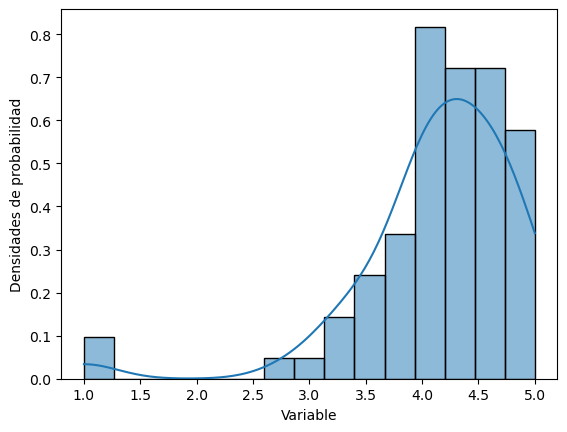

In [57]:
ax = sns.histplot(data=df_Mexico['product_star_rating'], stat='density', kde = True)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

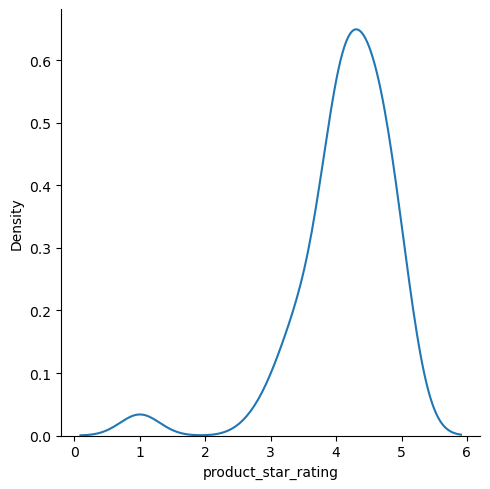

In [58]:
ax = sns.displot(df_Mexico['product_star_rating'], kind='kde')

Text(0, 0.5, 'Valores')

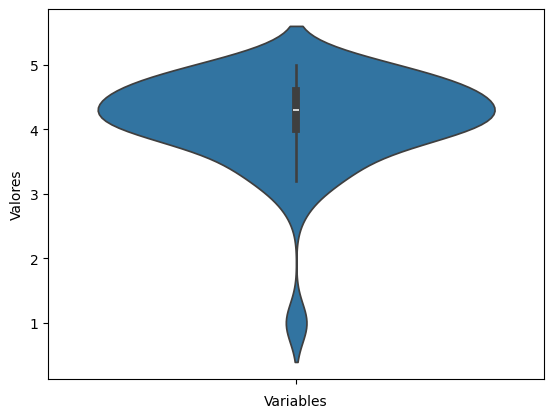

In [59]:
ax = sns.violinplot(data=df_Mexico['product_star_rating'])
ax.set_xlabel('Variables')
ax.set_ylabel('Valores')

Text(0, 0.5, 'Frecuencia')

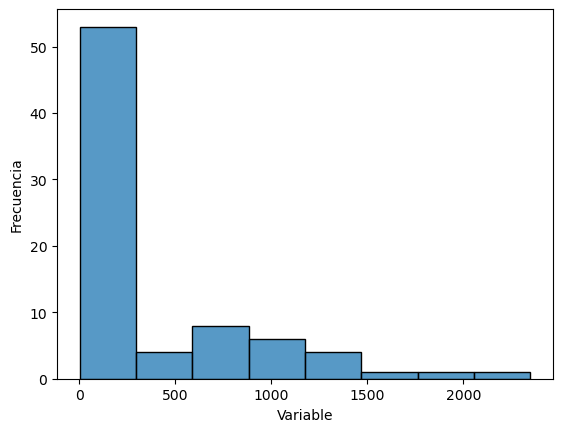

In [60]:
ax = sns.histplot(data=df_Mexico['product_num_ratings'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia')

Text(0, 0.5, 'Densidades de probabilidad')

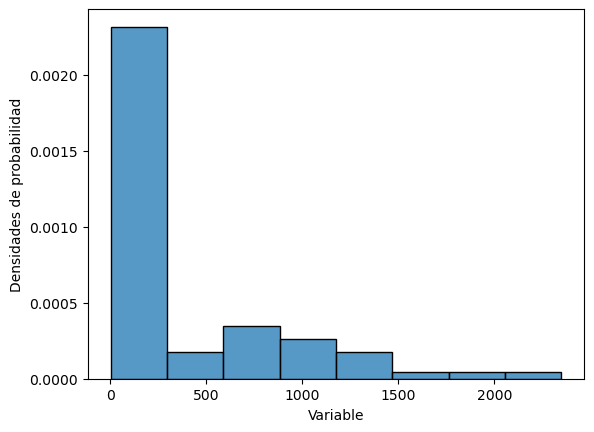

In [61]:
ax = sns.histplot(data=df_Mexico['product_num_ratings'], stat='density')
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

Text(0, 0.5, 'Densidades de probabilidad')

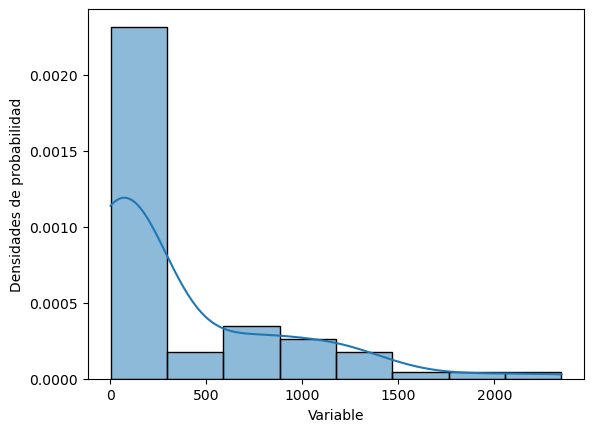

In [62]:
ax = sns.histplot(data=df_Mexico['product_num_ratings'], stat='density', kde = True)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

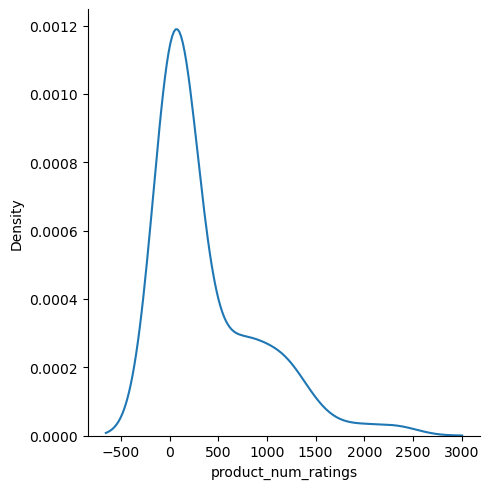

In [63]:
ax = sns.displot(df_Mexico['product_num_ratings'], kind='kde')

Text(0, 0.5, 'Valores')

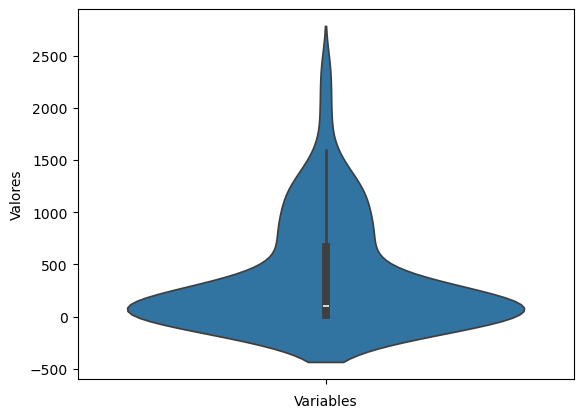

In [64]:
ax = sns.violinplot(data=df_Mexico['product_num_ratings'])
ax.set_xlabel('Variables')
ax.set_ylabel('Valores')